In [616]:
# pyright: reportOperatorIssue=false

In [617]:
from IPython.display import display, Math, Markdown
import typing

import sympy as sp
from sympy.printing.latex import LatexPrinter

## Setup

In [618]:
# Main parameters
dx = sp.Symbol('dx', real=True, positive=True)
dt = sp.Symbol('dt', real=True, positive=True)

a = sp.Symbol('a', real=True, positive=True)
cfl = sp.Symbol('cfl', real=True, positive=True)
sigma = sp.Symbol('sigma', latex=r'\sigma', real=True)

# dx and dt latex symbols (passed in sp.Symbol()) seem to be hard-coded to use 
# symbol names, this is a codegen-friendly work-around
symbol_names = {dx: r"\Delta x", dt: r"\Delta t", cfl: r"\nu"}
LatexPrinter.set_global_settings(symbol_names=symbol_names)

Since terms featured throughout (that utilize parameters of the method) are mainly of form $\Delta x^{\alpha} * \nu^{4 - \alpha}$ and can reach $1 / \Delta x^{4}$, it is necessary to pick right maximum order to leave high enough Big-$\mathcal{O}$ terms across all computations. Most symbols in operations are threated as constants, therefore they might get wholly (but conservatively) absorbed by $\mathcal{O}(\Delta x^{\alpha})$ terms -- that is without utilizing relanshionships between variables (such as $\Delta t \propto \Delta x$) in expansions and reducing total order when divided by powers of $\Delta x$.

*Note: this could be probably be more elegantly solved if one wishes to write `sympy` constraints.*

In [ ]:
# Derivatives
x = sp.Symbol('x', real=True)
u = sp.Function('u')
order = 9  # Expansion order = O(dx^9) -- the highest term kept is dx^9
derivs = [sp.Derivative(u(x), (x, i)) for i in range(0, order)]

In [620]:
# Stencil
u_im2 = sp.Symbol('u_im2')
u_im1 = sp.Symbol('u_im1')
u_i = sp.Symbol('u_i')
u_ip1 = sp.Symbol('u_ip1')
u_ip2 = sp.Symbol('u_ip2')
stencil = [u_im2, u_im1, u_i, u_ip1, u_ip2]

# This is just appears to be a better practice with sympy for consistency
symbol_names |= {
    stecil_point: "u^n_" + subscript for stecil_point, subscript in
    zip(stencil, ['{i - 2}', '{i - 1}', 'i', '{i + 1}', '{i + 2}'], strict=True)
}
LatexPrinter.set_global_settings(symbol_names=symbol_names)

stencil_taylors: typing.Mapping[sp.Basic | complex, sp.Expr] = {
    stecil_point: u(x + offset * dx).series(dx, 0, order).doit()
    for offset, stecil_point in enumerate(stencil, -2)
}

In [621]:
''' This cell is for small pretty printing utilities.

See

https://docs.sympy.org/latest/modules/printing.html#example-of-custom-printer

for examples.
'''

class BaseOrderedPrinter(LatexPrinter):
    '''
    Reusable Term Ordering Logic. Intercepts sympy.Add to sort terms based on 
    subclass priority rules.
    '''

    def _get_term_priority(self, term) -> tuple[int, int]:
        return (0, 0)

    def _print_Add(self, expr: sp.Expr, order=None):
        def priority_key(term):
            # Force Big-O terms to end
            if term.is_Order:
                return (99, 0)
            return self._get_term_priority(term)

        # Sort terms safely
        sorted_terms = sorted(expr.args, key=priority_key)
        ordered_expr = sp.Add(*sorted_terms, evaluate=False)

        # Print with sorting disabled so our order is respected
        old_order = self._settings.get('order')
        self._settings['order'] = 'none'
        result = super()._print_Add(ordered_expr, order='none')
        self._settings['order'] = old_order

        return result


class PrettyDerivativePrinter(LatexPrinter):
    ''' Only concerns itself with formatting u(x) and its derivatives. '''

    def _print_Function(self, expr: sp.Function, exp: sp.Expr | None = None):
        if getattr(expr.func, '__name__', '') == 'u':
            return f"u^{{{exp}}}" if exp is not None else "u"
        return super()._print_Function(expr, exp)

    def _print_Derivative(self, expr: sp.Derivative):
        func = expr.args[0]
        if getattr(getattr(func, 'func', None), '__name__', '') == 'u':
            n = len(expr.variables)
            var = expr.variables[0].name if expr.variables else 'x'
            sub = var * n

            if n == 0:
                return "u"
            elif n <= 3:
                return f"u_{{{sub}}}"
            else:
                roman = {4: 'IV', 5: 'V', 6: 'VI', 7: 'VII', 8: 'VIII'}
                return f"u^{{({roman.get(n, str(n))})}}_{{{sub}}}"

        return super()._print_Derivative(expr)


class StencilPrinter(BaseOrderedPrinter):
    ''' Sorts spatial stencil symbols. '''

    def __init__(self, settings=None):
        super().__init__(settings)
        self.stencil_syms = [
            sp.Symbol('u_im2'), sp.Symbol('u_im1'), sp.Symbol('u_i'),
            sp.Symbol('u_ip1'), sp.Symbol('u_ip2')
        ]

    def _get_term_priority(self, term):
        for i, sym in enumerate(self.stencil_syms):
            if term.has(sym):
                return (0, i)
        # Extra terms go at the end
        return (1, 0)


class SeriesPrinter(BaseOrderedPrinter, PrettyDerivativePrinter):
    ''' Sorts Taylor series by derivative degree and formats nicely. '''

    def _get_term_priority(self, term: sp.Expr):
        # Look for Derivative objects
        derivs = term.atoms(sp.Derivative)
        u_derivs = [deriv for deriv in derivs if getattr(
            getattr(deriv.args[0], 'func', None), '__name__', '') == 'u']
        if u_derivs:
            return (0, len(u_derivs[0].variables))

        # Look for base function u(x)
        funcs = term.atoms(sp.Function)
        u_funcs = [f for f in funcs if getattr(f.func, '__name__', '') == 'u']
        if u_funcs:
            return (0, 0)

        # Extra terms (constants, plain variables) go at the end
        return (1, 0)


def latex_stencil(expr: sp.Expr, **settings) -> str:
    return StencilPrinter(settings).doprint(expr)


def latex_series(expr: sp.Expr, **settings) -> str:
    return SeriesPrinter(settings).doprint(expr)

In [622]:
''' Sanity check '''
display(Markdown("Taylor expansions:"))
for stencil_point, expansion in stencil_taylors.items():
    if stencil_point != u_i: # Skip center point
        display(Math(fr"{sp.latex(stencil_point)} = {latex_series(expansion)} + \ldots"))

Taylor expansions:

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

## Method

In [623]:
u_next = \
    sigma * u_i + (1 - sigma) * (u_ip1 + u_im1) / 2 \
    + -a * dt * (u_ip1 - u_im1) / (2 * dx) \
    + (a * dt)**2 / 2 * (u_ip1 - 2 * u_i + u_im1) / dx**2

u_taylor: sp.Expr = u(x - a * dt).series(dt, 0, order)

In [624]:
def to_stencil_form(expr: sp.Expr) -> sp.Expr:
    """ Helper function """
    return sp.collect(sp.expand(expr), stencil)

In [625]:
# display(Markdown(""))
display(Math(
    f"u_i^{{n+1}} = {latex_stencil(sp.simplify(to_stencil_form(u_next)))}"
))
display(Math(
    f"u_i^{{n+1}} = {latex_series(sp.simplify(sp.collect(sp.expand(u_next.subs(stencil_taylors)), derivs)))}"
))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [626]:
def get_coeff(expr: sp.Expr, deriv: sp.Derivative) -> sp.Basic:
    return sp.together(sp.simplify(sp.expand(expr.doit()).coeff(deriv)))


u_next_taylor = sp.expand(u_next.subs(stencil_taylors))
error = sp.expand(u_next_taylor - u_taylor)

error_coeffs = [get_coeff(error, deriv) for deriv in derivs]

In [627]:
table = r"""
\begin{array} {r r r} \\
& \text{Coefficient} & \text{Error coefficient} \\
\hline \\
"""

# # Decorative purpose only
# pretty_derivs_symbol_names = {
#     deriv: fr"\dfrac{{\partial^{k} u}}{{\partial x^{k}}}"
#     for k, deriv in enumerate(derivs)
# } | {u: "u", u_x: r"\dfrac{\partial u}{\partial x}"}

# for deriv, error_coeff in zip(derivs, error_coeffs):
#     table += fr"{sp.latex(deriv, symbol_names=pretty_derivs_symbol_names)} : &\quad \
#                     {sp.latex(get_coeff(u_next_taylor, deriv), fold_short_frac=True)} &\quad \
#                     {sp.latex(error_coeff, fold_short_frac=True)} \\[1em]"

table += r"\end{array}"
display(Math(table))

<IPython.core.display.Math object>

The goal here is to strip away the common factors (like $\Delta t$, $\Delta x$, and factorial denominators from the Taylor series) to isolate the "raw" constants of the error.
*   **`* sp.factorial(k)`**: Cancels out the $1/k!$ term from the Taylor expansion.
*   **`* 6 / (a**3 * dt**3 * dx**k)`**: The leading order of the error for this specific scheme is expected to be $O(a^3 \Delta t^3)$. Dividing by this normalizes the error terms, essentially asking: *"What is the coefficient of the $k$-th derivative relative to the leading error term?"*

In [628]:
error_vector = sp.Matrix([error_coeffs[k] for k in range(5)])
# IMPORTANT adjustment that determines the order (4th) and value of error
error_vector[4] -= ((sigma - 1) * dx**4) / 24

display(Math(fr"{sp.latex(sp.simplify(error_vector.T))}^T"))

<IPython.core.display.Math object>

This creates a $5 \times 5$ matrix representing the "structure" of the 5-point stencil ($u_{i-2}$ to $u_{i+2}$). 
*   Each row corresponds to a derivative order $k$ ($0, 1, 2, 3, 4$).
*   Each column corresponds to a stencil offset ($-2, -1, 0, 1, 2$).
*   Because we already accounted for $1/k!$ and $\Delta x^k$ in the normalization step, the Taylor coefficient for offset $j$ and order $k$ is simply $j^k$. (The `0**k if k > 0 else 1` handles the $0^0 = 1$ edge case for the $u_i$ term).

In [629]:
taylor_matrix = sp.Matrix([
    [(j * dx)**k / sp.factorial(k) for j in (-2, -1, 0, 1, 2)]
    for k in range(5)
])

# more readable format
normalization = sp.diag(*[sp.factorial(k) / dx**k for k in range(5)])

display(Math(
    fr"{sp.latex(sp.simplify(normalization * taylor_matrix))} x = \
        \cdot {sp.latex(sp.simplify(normalization * error_vector))}"
))

correction_coeffs: sp.Matrix = taylor_matrix.solve(error_vector)

# pretty printing factoring out of denominator
gcd = 24 * dx**4
display(Math(
    fr"x = {sp.latex(1 / gcd)} \cdot {sp.latex(sp.simplify(correction_coeffs * gcd))}"
))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [630]:
correction_term: sp.Expr = -correction_coeffs.dot(stencil)
u_corrected = u_next + correction_term
u_corrected_taylor = sp.expand(u_corrected.subs(stencil_taylors))
error_corrected = sp.expand(u_corrected_taylor - u_taylor)

In [688]:
correction_coeffs[4]

(-a**4*dt**4 + 2*a**3*dt**3*dx + a**2*dt**2*dx**2 - 2*a*dt*dx**3 - dx**4*sigma + dx**4)/(24*dx**4)

In [686]:
# sp.simplify(u_corrected)
(correction_coeffs[4] * u_ip2).subs(stencil_taylors)

(-a**4*dt**4 + 2*a**3*dt**3*dx + a**2*dt**2*dx**2 - 2*a*dt*dx**3 - dx**4*sigma + dx**4)*(u(x) + 2*dx*Derivative(u(x), x) + 2*dx**2*Derivative(u(x), (x, 2)) + 4*dx**3*Derivative(u(x), (x, 3))/3 + 2*dx**4*Derivative(u(x), (x, 4))/3 + 4*dx**5*Derivative(u(x), (x, 5))/15 + 4*dx**6*Derivative(u(x), (x, 6))/45 + 8*dx**7*Derivative(u(x), (x, 7))/315 + 2*dx**8*Derivative(u(x), (x, 8))/315 + O(dx**9))/(24*dx**4)

In [632]:
display(Math(
    latex_stencil(sp.simplify(to_stencil_form(u_corrected)), long_frac_ratio=1)
))

<IPython.core.display.Math object>

In [687]:
for deriv in derivs:
    coeff = sp.simplify(get_coeff(error_corrected, deriv))
    if coeff != 0:
        display(Markdown("Coefficient of highest-order error term ${}$:"
                         .format(PrettyDerivativePrinter().doprint(deriv))))
        display(Math(f"{sp.latex(coeff)}"))
        break

Coefficient of highest-order error term $u^{(IV)}_{xxxx}$:

<IPython.core.display.Math object>

In [634]:
u_corrected_cfl: sp.Expr = sp.simplify(u_corrected.subs(a*dt, cfl*dx))

# Sanity checks
assert u_corrected_cfl.coeff(a) == 0 and u_corrected_cfl.coeff(dt) == 0, \
    "Unexpected form after rewrite"

stencil_points_coeffs = [
    typing.cast(
        sp.Expr,
        sp.simplify(sp.expand(u_corrected_cfl).coeff(stencil_point)) # type: ignore
    )  
    for stencil_point in stencil]

# Requires `simplify` *somewhere*
assert sum(stencil_points_coeffs) == 1, "Coefficients don't sum to 1"

In [635]:
display(Markdown("Complete numerical scheme (CFL form):"))

display(Math(
    fr"u_i^{{n+1}} = {latex_stencil(sp.simplify(to_stencil_form(u_corrected_cfl)))}"
))

display(Math(
    latex_series(sp.collect(sp.simplify(u_corrected_cfl.subs(stencil_taylors).doit()), derivs))
))

Complete numerical scheme (CFL form):

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [636]:
def save_to_python_module(expr, filename: str = "mlf_method.py"):
    """Save the complete method as a Python module."""
    
    module_content = f'''
"""
Programmatically-generated Lax-Friedrichs-type 4th-order scheme for solving the
advection equation.
"""

import numpy as np
import numpy.typing as npt

def mlf_step(
    u: npt.NDArray[np.floating],
    dx: np.floating, cfl: np.floating, sigma: np.floating, **_,
) -> npt.NDArray[np.floating]:
    """
    Apply the method using array indexing.
    
    Parameters
    ----------
    u
        Current solution array
    dx
        Spatial step size
    cfl
        CFL number (nu = a*dt/dx)
    sigma
        Dissipation parameter
    
    Returns
    -------
    u_next
        Updated value(s)
    """
    u_next = np.zeros_like(u)
    i = np.arange(2, len(u) - 2)

    u_im2 = u[i-2]
    u_im1 = u[i-1]
    u_i = u[i]
    u_ip1 = u[i+1]
    u_ip2 = u[i+2]

    # TODO -- add mypy warning supression
    # pylint: disable=line-too-long
    u_next[i] = {sp.printing.pycode(expr)}
    return u_next
'''
    
    with open(filename, 'w') as file:
        file.write(module_content)
        print(f"Saved method to {filename}")
    

save_to_python_module(u_corrected_cfl, "mlf_method.py")

Saved method to mlf_method.py


## Stability analysis

In [637]:
def amplification_factor(coeffs: list, theta: sp.Symbol) -> sp.Expr:
    """Return G(theta) = sum c_j * exp(I * j * theta)."""
    I = sp.I  # noqa: E741
    j_vals = [-2, -1, 0, 1, 2]
    G = sum(c * sp.exp(I * j * theta) for c, j in zip(coeffs, j_vals))
    return sp.simplify(G)

In [638]:
def squared_modulus(G: sp.Expr, theta: sp.Symbol) -> sp.Expr:
    import typing

    """Return |G|^2 as a real trigonometric expression in theta."""
    G_conjugate = typing.cast(sp.Expr, sp.conjugate(G)).replace(sp.conjugate(theta), theta)  # theta is real
    G_mod_sq = sp.simplify(sp.expand_complex(G * G_conjugate))
    return G_mod_sq

In [639]:
def critical_thetas(G: sp.Expr, theta: sp.Symbol) -> list:
    """Find stationary points of |G|^2 w.r.t. theta in [0, pi]."""
    d_mod = sp.simplify(sp.diff(squared_modulus(G, theta), theta))
    # solve d_mod = 0; often yields simple trigonometric equations
    solutions = sp.solve(d_mod, theta, domain=sp.Interval(0, sp.pi))
    return list(solutions)

In [640]:
def analytical_stability_condition(coeffs: list, cfl: sp.Symbol, theta: sp.Symbol) -> sp.Expr:
    """
    Attempt to find the condition on cfl such that |G|^2 <= 1 for all theta.
    Often works by substituting the worst-case theta (e.g., theta=pi) and solving.
    """
    G = amplification_factor(coeffs, theta)
    G_mod_sq = squared_modulus(G, theta)
    
    # For many upwind/central schemes the maximum occurs at theta = pi or 0
    worst_cases = [0, sp.pi]
    conditions = [G_mod_sq.subs(theta, tc) <= 1 for tc in worst_cases]
    # Solve inequalities
    cfl_cond = sp.simplify(sp.solve_univariate_inequality(conditions[0] & conditions[1], cfl))
    return cfl_cond

In [641]:
theta = sp.Symbol('theta', real=True)

coeffs = stencil_points_coeffs

In [642]:
G = amplification_factor(coeffs, theta)

display(Markdown("Amplification factor:"))
display(G)

# G_mod_sq = squared_modulus(G, theta)
# display(G_mod_sq)

Amplification factor:

(cfl**4 + 2*cfl**3 - cfl**2 - 2*cfl + sigma + 4*(-cfl**4 - cfl**3 + 4*cfl**2 + 4*cfl - sigma + 1)*exp(I*theta) + (6*cfl**4 - 30*cfl**2 + 6*sigma + 4*(-cfl**4 + cfl**3 + 4*cfl**2 - 4*cfl - sigma + 1)*exp(I*theta) + (cfl**4 - 2*cfl**3 - cfl**2 + 2*cfl + sigma - 1)*exp(2*I*theta) + 18)*exp(2*I*theta) - 1)*exp(-2*I*theta)/24

In [643]:
# critical_thetas(G, theta)

In [644]:
# cond = analytical_stability_condition(coeffs, cfl, theta)
# try:
#     print("Stability condition:", cond)
# except Exception:
#     print("Analytical approach failed, falling back to numerics.")

In [645]:
def critical_thetas(G: sp.Expr, theta: sp.Symbol) -> list:
    """Find stationary points of |G|^2 w.r.t. theta in [0, 2π]."""
    G_mod_sq = squared_modulus(G, theta)
    d_mod = sp.simplify(sp.diff(G_mod_sq, theta))
    
    display(d_mod)
    # Solve in full period [0, 2π] since the function is periodic
    solutions = sp.solve(d_mod, theta, domain=sp.Interval(0, 2*sp.pi))
    
    # Also check boundary points
    critical_points = list(solutions) + [0, 2*sp.pi]
    
    # Remove duplicates and sort
    critical_points = sorted(list(set(critical_points)))
    
    return critical_points

In [646]:
# critical_thetas(G, theta)

In [647]:
# G_mod_sq

### Stability bounds

In [648]:
G_mod_sq = squared_modulus(G, theta)
# d_mod = sp.trigsimp(sp.diff(G_mod_sq, theta))

$|G|^2$ contains only even powers of $\nu$ (CFL), so we set $\mu = \nu^2$ to keep the algebra low‑degree.  

Stability requires $\max_{x\in[-1,1]} P(x,\mu) \le 1$. For a consistent centred scheme one usually has $P(1)=P(-1)=1$; the first violation occurs when an interior maximum touches $1$. That gives the system  
$P(x,\mu)-1 = 0,\quad \partial P/\partial x = 0,$ which we eliminate $x$ from via a resultant. The result is a polynomial in $\mu$ whose smallest positive root is $\mu_{\max}$. The CFL limit is $\nu_{\max} = \sqrt{\mu_{\max}}$.

*Expected result:*  
`stability_eq` is an algebraic equation $F(\mu, \sigma) = 0$. In many cases it factors into a product of polynomials. The factor that gives the smallest positive $\mu$ is the one we care about. For example, you may get an equation like  
$$
a(\sigma)\,\mu^3 + b(\sigma)\,\mu^2 + c(\sigma)\,\mu + d(\sigma) = 0,
$$  
or even a quadratic/linear factor. The stability condition is then  
$$
|\nu| \le \sqrt{\mu_{\max}(\sigma)}.
$$

If the degree in $\mu$ is ≤4, you can solve analytically; otherwise, `nroots` gives the numerical limit for any given $\sigma$.

*Note on boundaries:*  
If `sp.simplify(P.subs(x, 1))` or `P.subs(x, -1)` is not identically 1, you must also check that `P( ±1, mu) ≤ 1`. Those give separate polynomial inequalities in $\mu$ that may cut the allowed interval before the interior hump does. The overall $\mu_{\max}$ is the smallest positive number at which any of these constraints becomes violated. In practice, for a 5‑point centred 4th‑order scheme, the interior critical point typically dictates the bound.

In [649]:
# x = sp.Symbol('x', real=True)

# expr = sp.simplify(G_mod_sq)
# expr = sp.expand_trig(expr)
# # Replace sin(theta)^2 -> 1 - cos(theta)^2
# expr_cos = expr.subs(sp.sin(theta)**2, 1 - sp.cos(theta)**2)
# # Replace cos(theta) -> x
# P_x_cfl = sp.simplify(expr_cos.subs(sp.cos(theta), x))
# P_x_cfl

In [650]:
# mu = sp.Symbol('mu', nonnegative=True, real=True)
# # Substitute cfl^2 -> mu; also handle (cfl^2)^2 etc. by substituting powers.
# # A reliable way: replace cfl by sqrt(mu) and then simplify assuming mu>0.
# P = sp.simplify(P_x_cfl.subs(cfl, sp.sqrt(mu)))
# P

In [651]:
# P_poly = sp.Poly(P, x)
# P_prime_poly = sp.Poly(sp.diff(P, x), x)

# # Equations for an interior point x0 where P = 1 and P' = 0
# # (We use the same dummy x0 to build the resultant, but it's the same variable anyway.)
# res = sp.resultant(P_poly - sp.Poly(1, x), P_prime_poly, x)
# # res is a polynomial expression in mu and sigma.
# res

In [652]:
# sp.simplify(P.subs(mu, 0))

In [653]:
x = sp.Symbol('x', real=True)
mu = sp.Symbol('mu', nonnegative=True, real=True)

# Trigonometric reduction: sin^2 -> 1 - cos^2
# same as expand(trig=True)?
expr = sp.expand_trig(sp.simplify(G_mod_sq))
P_x_cfl = sp.simplify(
    expr.subs(sp.sin(theta)**2, 1 - sp.cos(theta)**2)
         .subs(sp.cos(theta), x)
)

# Verify it's polynomial in x (should pass)
assert P_x_cfl.is_polynomial(x)

# Use mu = cfl^2 (only even powers appear)
P = sp.simplify(P_x_cfl.subs(cfl, sp.sqrt(mu)))

# Derivative with respect to x
dP_dx = sp.diff(P, x)

# 1) Interior critical points: P = 1 and dP/dx = 0
res = sp.resultant(P - 1, dP_dx, x)
res = sp.simplify(res)                          # polynomial in mu, sigma


In [654]:
end1 = sp.simplify(P.subs(x,  1) - 1)           # condition at x = 1
end2 = sp.simplify(P.subs(x, -1) - 1)           # condition at x = -1

# Because mu=0 is almost always a solution (identity operator), we can factor it out
# to avoid zero-trivial root.
def factor_out_mu(expr):
    """Return the part of expr that gives non-zero mu solutions."""
    # expr may factor; extract factor(s) that vanish for positive mu.
    # We simply remove any factor `mu` or `mu**k`.
    fac = sp.factor(expr)
    if fac.is_Pow:
        if fac.args[0] == mu:
            return sp.S.Zero   # only trivially mu=0
        else:
            return fac
    if fac.is_Mul:
        non_mu_factors = [f for f in fac.args if not (f.is_Pow and f.args[0]==mu) and f != mu]
        return sp.Mul(*non_mu_factors)
    return fac

res_eq = sp.simplify(factor_out_mu(res))
end1_eq = sp.simplify(factor_out_mu(end1))
end2_eq = sp.simplify(factor_out_mu(end2))

# ----- Presentation -----
print("Stability equations (smallest positive mu from these gives mu_max):")
print("Interior critical points:")
display(res_eq)
print("\nEndpoint x = +1:")
display(end1_eq)
print("\nEndpoint x = -1:")
display(end2_eq)


Stability equations (smallest positive mu from these gives mu_max):
Interior critical points:


0


Endpoint x = +1:


0


Endpoint x = -1:


4*(mu**2 - 4*mu + sigma - 1)*(mu**2 - 4*mu + sigma + 2)/9

In [655]:
end2_num = end2_eq.subs(sigma, 0.5)

In [656]:
end2_eq

4*(mu**2 - 4*mu + sigma - 1)*(mu**2 - 4*mu + sigma + 2)/9

In [657]:
# bob = sp.Poly(end2_eq, mu)
# bob

# if bob.degree() > 0:
#             # numerical root finding
#             # use nroots for degree > 0
#             for r in bob.nroots():
#                 if abs(sp.im(r)) < 1e-12 and sp.re(r) > 0:
#                     print(r)


In [658]:
def nu_max_for_sigma(sigma_val):
    """Numerically find nu_max for a given sigma value."""
    # Substitute sigma value
    res_num = res_eq.subs(sigma, sigma_val)
    end1_num = end1_eq.subs(sigma, sigma_val)
    end2_num = end2_eq.subs(sigma, sigma_val)
    
    # Collect all positive real roots of mu
    positive_roots = []
    for eq in [res_num, end1_num, end2_num]:
        if eq.is_number and eq == 0:
            # any mu works? unlikely, but skip
            continue
        # convert to polynomial in mu
        poly = sp.Poly(eq, mu)
        if poly.degree() > 0:
            # numerical root finding
            # use nroots for degree > 0

            positive_roots = map(sp.re, filter(lambda root: abs(sp.im(root)) < 1e-12 and sp.re(root)  > 0, poly.nroots()))
            # for r in poly.nroots():
            #     if abs(sp.im(r)) < 1e-12 and sp.re(r) > 0:
            #         print(r)
            #         roots.append(float(sp.re(r)))
    if not positive_roots:
        return float('inf')  # unconditionally stable
    mu_max = min(positive_roots)
    return sp.sqrt(mu_max)

In [659]:
nu_max_for_sigma(0.5)

0.880485734471837

In [660]:
# Q = sp.simplify(d_mod / sp.sin(theta))

In [661]:
# Q_poly = sp.together(sp.ratsimp(sp.expand_trig(Q)).subs(sp.sin(theta)**2, 1 - sp.cos(theta)**2))

In [662]:
# display(Math(sp.latex(Q_poly, fold_func_brackets=True, long_frac_ratio=0)))

In [663]:
# sp.simplify(G_mod_sq)

In [664]:
# x = sp.Symbol('x', real=True)
# y = sp.Symbol('y', real=True)

# Q_poly = sp.simplify(Q_poly.subs(sp.cos(theta), x).subs(cfl**2, y))
# assert Q_poly.is_polynomial(x, y)

In [665]:
# display(Math(sp.latex(Q_poly, fold_func_brackets=True, long_frac_ratio=0)))

In [666]:
# Q_poly = sp.simplify(Q_cos.subs(sp.cos(theta), x))

In [667]:
# if Q_poly == 0:
#     ...
#     # In this degenerate case every θ is stationary; return a representation.
#     # return [theta]  # the user can later substitute numeric values

# x_roots = sp.solve(Q_poly, x)   # list of roots (may contain conditional expressions)

# # 6. Convert each admissible root x₀ ∈ [-1,1] back to θ
# critical_points = []
# for root in x_roots:
#     # We keep roots as symbolic expressions; the condition |root|≤1 is assumed.
#     # For each root inside [-1,1] there are two solutions in [0,2π]:
#     # θ = arccos(x₀)  and  θ = 2π - arccos(x₀)
#     # For x₀ = ±1 they coincide, but we can keep both; the final set will deduplicate.
#     theta1 = sp.acos(root)
#     theta2 = 2*sp.pi - sp.acos(root)
#     critical_points.extend([theta1, theta2])

# # 7. Add the points where sinθ = 0 (which we divided out)
# critical_points.extend([0, sp.pi, 2*sp.pi])

# # 8. Remove duplicates and sort (sorting symbolic expressions may be approximate)
# #    Using dict keeps order but eliminates identical expressions.
# critical_points = list(dict.fromkeys(critical_points))
# # Optional: sort by string representation or simply return as is.
# critical_points.sort(key=str)


In [668]:
# Q_poly

In [669]:
# critical_points

In [670]:

# y = sp.Symbol('y', positive=True)

# A = [d_mod.subs(cfl**2, y).coeff(sp.sin(k*theta), 1) for k in range(1, 5)]
    
# # Critical points: sin(θ) = 0 or polynomial part = 0
# critical_points = [0, sp.pi, 2*sp.pi]

# # Set up polynomial equation in x = sin²(θ)
# x = sp.Symbol('x', nonnegative=True)  # x = sin²(θ)

# # The polynomial part (coefficient of sin(θ)) is:
# # A[0] + A[1]×2√(1-x) + A[2]×(3-4x) + A[3]×4√(1-x)×(1-2x)

# # Group terms: [A[0] + A[2]×(3-4x)] + √(1-x)×[2A[1] + 4A[3]×(1-2x)]
# no_sqrt = A[0] + A[2]*(3 - 4*x)
# sqrt_coeff = 2*A[1] + 4*A[3]*(1 - 2*x)

# # For critical points: no_sqrt + √(1-x)×sqrt_coeff = 0
# # So: √(1-x)×sqrt_coeff = -no_sqrt
# # Square both sides: (1-x)×sqrt_coeff² = no_sqrt²

# try:
#     if sqrt_coeff != 0:
#         equation = (1 - x) * sqrt_coeff**2 - no_sqrt**2
#         x_solutions = sp.solve(equation, x)
        
#         for sol in x_solutions:
#             if sol.is_real and 0 <= sol <= 1:
#                 if sol > 0:
#                     sqrt_sol = sp.sqrt(sol)
#                     critical_points.extend([
#                         sp.asin(sqrt_sol),
#                         sp.pi - sp.asin(sqrt_sol)
#                     ])
#     else:
#         # Only no_sqrt terms
#         x_solutions = sp.solve(no_sqrt, x)
#         for sol in x_solutions:
#             if sol.is_real and 0 <= sol <= 1:
#                 if sol > 0:
#                     sqrt_sol = sp.sqrt(sol)
#                     critical_points.extend([
#                         sp.asin(sqrt_sol),
#                         sp.pi - sp.asin(sqrt_sol)
#                     ])
                    
# except Exception as e:
#     print(f"Polynomial solving failed: {e}")

# sorted(list(set(critical_points)))
# # return sorted(list(set(critical_points)))

In [671]:
def analytical_stability_condition(coeffs: list, cfl: sp.Symbol, theta: sp.Symbol, sigma_val=None) -> sp.Expr:
    """
    Find condition on CFL for stability by checking critical theta values.
    """
    G = amplification_factor(coeffs, theta)
    G_mod_sq = squared_modulus(G, theta)
    
    # If sigma has a specific value, substitute it
    if sigma_val is not None:
        G_mod_sq = G_mod_sq.subs(sigma, sigma_val)
    
    # Find critical points
    critical_points = critical_thetas(G, theta)
    
    # Also check some known problematic points for advection schemes
    test_points = [0, sp.pi, sp.pi/2, 3*sp.pi/2] + critical_points
    
    conditions = []
    for tc in test_points:
        try:
            condition = G_mod_sq.subs(theta, tc) <= 1
            conditions.append(condition)
        except:
            continue
    
    # For stability, ALL conditions must be satisfied
    # This is more complex than just checking θ=0 and θ=π
    return conditions


In [672]:
# cond = analytical_stability_condition(coeffs, cfl, theta)
# cond
# try:
#     print("Stability condition:", cond)
# except Exception:
#     print("Analytical approach failed, falling back to numerics.")

### Numerical results

In [673]:
import typing

import numpy as np
import numpy.typing as npt
import matplotlib.pyplot as plt
import matplotlib.axes

In [674]:
G_numeric: typing.Callable[
    [npt.ArrayLike, npt.ArrayLike, np.floating],
    npt.NDArray[np.floating]
] = sp.lambdify((theta, cfl, sigma), G, modules='numpy')

In [675]:

def find_stability_bound_numerically(coeffs: list, sigma_val: float, 
                                    cfl_range: tuple[float, float] = (0.01, 2.0)) -> float:
    """Numerically find maximum stable CFL for given sigma."""
    theta_test = np.linspace(0, 2*np.pi, 1000)
    
    for cfl_test in np.linspace(cfl_range[1], cfl_range[0], 500):
        G_values = G_numeric(theta_test, cfl_test, sigma_val)
        if np.all(np.abs(G_values)**2 <= 1.0 + 1e-12):
            return cfl_test
    
    return None  # No stable CFL found

In [676]:
def plot_stability_region(sigma_values: typing.Sequence[float]=(0.0, 0.5, 1.0),
                          theta_range: tuple[float, float] = (0.0, 2*np.pi),
                          cfl_range: tuple[float, float] = (0.01, 1.5),
                          n_theta=200, n_cfl=100):
    """Numerically compute and plot |G|^2 over pairs $(\\theta, \\nu)$ for several $\\sigma$."""
    theta_values = np.linspace(*theta_range, n_theta)
    cfl_values = np.linspace(*cfl_range,   n_cfl)
    THETA, CFL = np.meshgrid(theta_values, cfl_values)

    fig, axes = plt.subplots(1, len(sigma_values),
                             figsize=(5 * len(sigma_values), 4),
                             squeeze=False)

    for ax, sigma_value in zip(axes[0], sigma_values):
        ax: matplotlib.axes.Axes
        G_values = G_numeric(THETA, CFL, sigma_value)
        G_mod_sq = np.abs(G_values)**2

        contour = ax.contourf(THETA, CFL, G_mod_sq, levels=50, cmap='RdYlGn_r')
        ax.contour(THETA, CFL, G_mod_sq, levels=[1.0],
                   colors='black', linewidths=2)

        # TODO -- Here and everywhere we should probably use rational multiples
        # of pi as ticks
        ax.set_xlabel(r'Wavenumber $\theta = k\,\Delta x$')
        ax.set_ylabel(r'CFL-number $\nu$')
        ax.set_title(rf'$\sigma = {sigma_value}$,  $|G|^2$')
        fig.colorbar(contour, ax=ax, label=r'$|G|^2$')

    fig.tight_layout()
    plt.show()

    # Maximum stable CFL per sigma
    print("\nMaximum stable CFL (|G|² ≤ 1 for all θ):")
    fine_theta = np.linspace(*theta_range, 1000)
    for sig in sigma_values:
        cfl_max = None
        for cfl_test in np.linspace(cfl_range[1], cfl_range[0], 600):
            G_values = G_numeric(fine_theta, cfl_test, sig)
            if np.all(np.abs(G_values)**2 <= 1.0 + 1e-10):
                cfl_max = cfl_test
                break
        if cfl_max is not None:
            print(f"  σ = {sig}: ν_max ≈ {cfl_max:.4f}")
        else:
            print(f"  σ = {sig}: no stable ν found in {cfl_range}")

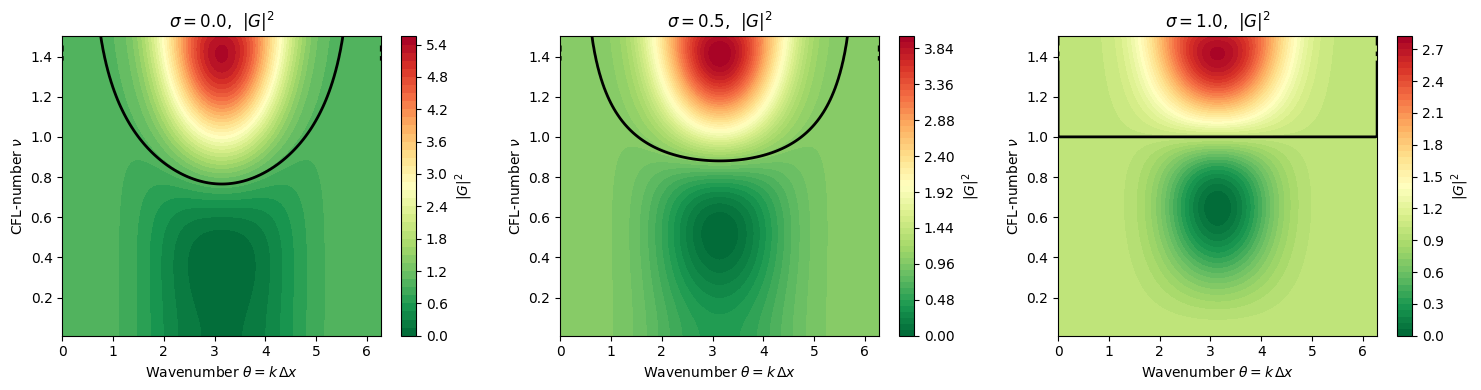


Maximum stable CFL (|G|² ≤ 1 for all θ):
  σ = 0.0: ν_max ≈ 0.7637
  σ = 0.5: ν_max ≈ 0.8781
  σ = 1.0: ν_max ≈ 0.9975


In [677]:
plot_stability_region(sigma_values=(0.0, 0.5, 1.0))

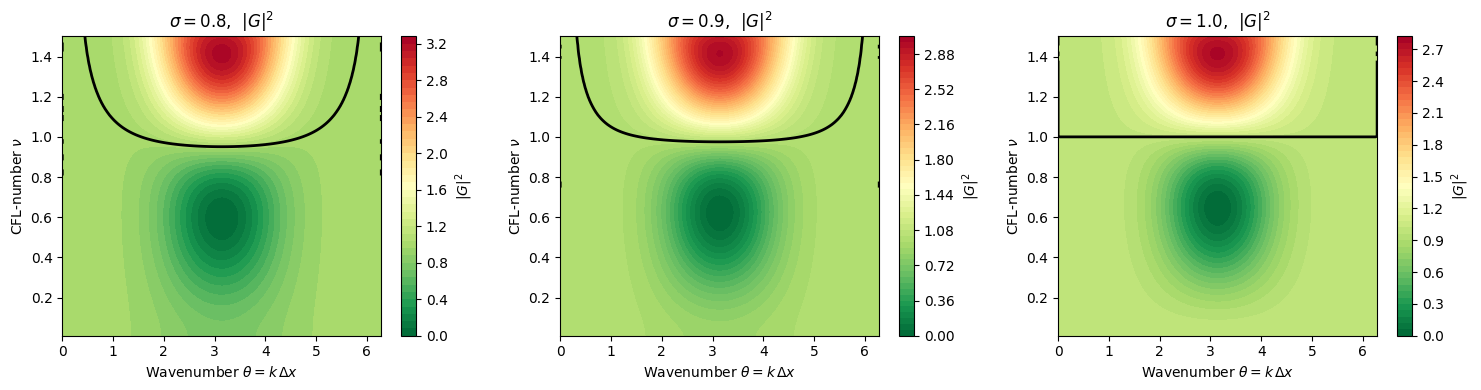


Maximum stable CFL (|G|² ≤ 1 for all θ):
  σ = 0.8: ν_max ≈ 0.9503
  σ = 0.9: ν_max ≈ 0.9751
  σ = 1.0: ν_max ≈ 0.9975


In [678]:
plot_stability_region(sigma_values=(0.8, 0.9, 1.0))

In [679]:
def plot_3d_stability_surface(sigma_range: tuple[float, float] = (0.0, 2.0),
                             theta_range: tuple[float, float] = (0.0, 2*np.pi),
                             cfl_range: tuple[float, float] = (0.01, 1.5),
                             n_sigma=20, n_theta=100, n_cfl=80):
    """3D surface plot showing |G|^2 = 1 stability boundary."""
    
    # Create grid
    sigma_vals = np.linspace(*sigma_range, n_sigma)
    theta_vals = np.linspace(*theta_range, n_theta)
    cfl_vals = np.linspace(*cfl_range, n_cfl)
    
    # Find stability boundary for each (sigma, theta) pair
    SIGMA, THETA = np.meshgrid(sigma_vals, theta_vals)
    CFL_BOUNDARY = np.zeros_like(SIGMA)
    
    for i, sig in enumerate(sigma_vals):
        for j, th in enumerate(theta_vals):
            # Binary search for CFL where |G|^2 = 1
            cfl_low, cfl_high = cfl_range
            for _ in range(50):  # Binary search iterations
                cfl_mid = (cfl_low + cfl_high) / 2
                G_val = G_numeric(th, cfl_mid, sig)
                if np.abs(G_val)**2 > 1.0:
                    cfl_high = cfl_mid
                else:
                    cfl_low = cfl_mid
            CFL_BOUNDARY[j, i] = cfl_mid
    
    # 3D surface plot
    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(111, projection='3d')
    
    surf = ax.plot_surface(SIGMA, THETA, CFL_BOUNDARY, 
                          cmap='viridis', alpha=0.8)
    
    ax.set_xlabel(r'Parameter $\sigma$')
    ax.set_ylabel(r'Wavenumber $\theta$')
    ax.set_zlabel(r'Critical CFL $\nu_{max}$')
    ax.set_title('Stability Boundary Surface')
    
    plt.colorbar(surf, shrink=0.5)
    plt.show()

def plot_max_cfl_vs_sigma(sigma_range: tuple[float, float] = (0.0, 2.0),
                         theta_range: tuple[float, float] = (0.0, 2*np.pi),
                         cfl_range: tuple[float, float] = (0.01, 1.5),
                         n_sigma=100):
    """Plot maximum stable CFL as function of sigma."""
    
    sigma_vals = np.linspace(*sigma_range, n_sigma)
    max_cfl_vals = []
    
    fine_theta = np.linspace(*theta_range, 500)
    
    for sig in sigma_vals:
        cfl_max = None
        for cfl_test in np.linspace(cfl_range[1], cfl_range[0], 300):
            G_values = G_numeric(fine_theta, cfl_test, sig)
            if np.all(np.abs(G_values)**2 <= 1.0 + 1e-12):
                cfl_max = cfl_test
                break
        max_cfl_vals.append(cfl_max if cfl_max is not None else 0)
    
    plt.figure(figsize=(10, 6))
    plt.plot(sigma_vals, max_cfl_vals, 'b-', linewidth=2)
    plt.xlabel(r'Parameter $\sigma$')
    plt.ylabel(r'Maximum stable CFL $\nu_{max}$')
    plt.title('Maximum Stable CFL vs Parameter σ')
    plt.grid(True, alpha=0.3)
    plt.show()

def plot_stability_contours_multi_sigma(sigma_values: list[float] = [0.0, 0.2, 0.5, 0.8, 1.0],
                                       theta_range: tuple[float, float] = (0.0, 2*np.pi),
                                       cfl_range: tuple[float, float] = (0.01, 1.5)):
    """Plot stability boundary contours for multiple sigma values on same plot."""
    
    theta_vals = np.linspace(*theta_range, 300)
    
    plt.figure(figsize=(10, 8))
    
    colors = plt.colormaps['viridis'](np.linspace(0, 1, len(sigma_values)))
    
    for sig, color in zip(sigma_values, colors):
        cfl_boundary = []
        for th in theta_vals:
            # Binary search for boundary CFL
            cfl_low, cfl_high = cfl_range
            for _ in range(40):
                cfl_mid = (cfl_low + cfl_high) / 2
                G_val = G_numeric(th, cfl_mid, sig)
                if np.abs(G_val)**2 > 1.0:
                    cfl_high = cfl_mid
                else:
                    cfl_low = cfl_mid
            cfl_boundary.append(cfl_mid)
        
        plt.plot(theta_vals, cfl_boundary, color=color, 
                linewidth=2, label=f'σ = {sig}')
    
    plt.xlabel(r'Wavenumber $\theta$')
    plt.ylabel(r'Critical CFL $\nu_{max}$')
    plt.title('Stability Boundaries for Various σ')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

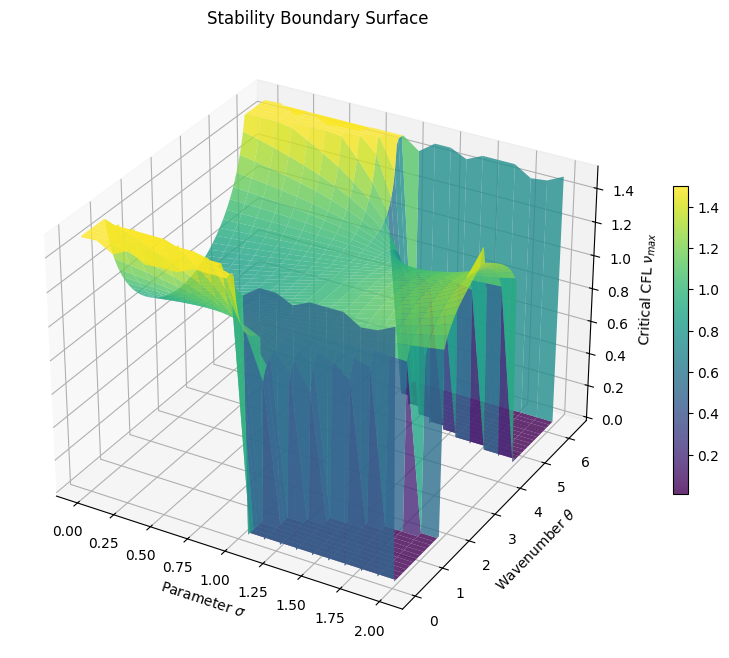

In [680]:
plot_3d_stability_surface()

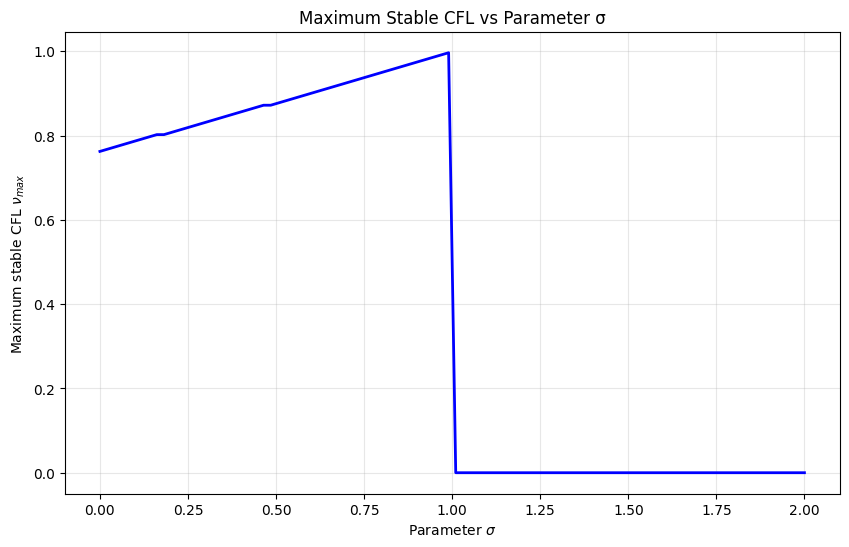

In [681]:
plot_max_cfl_vs_sigma()

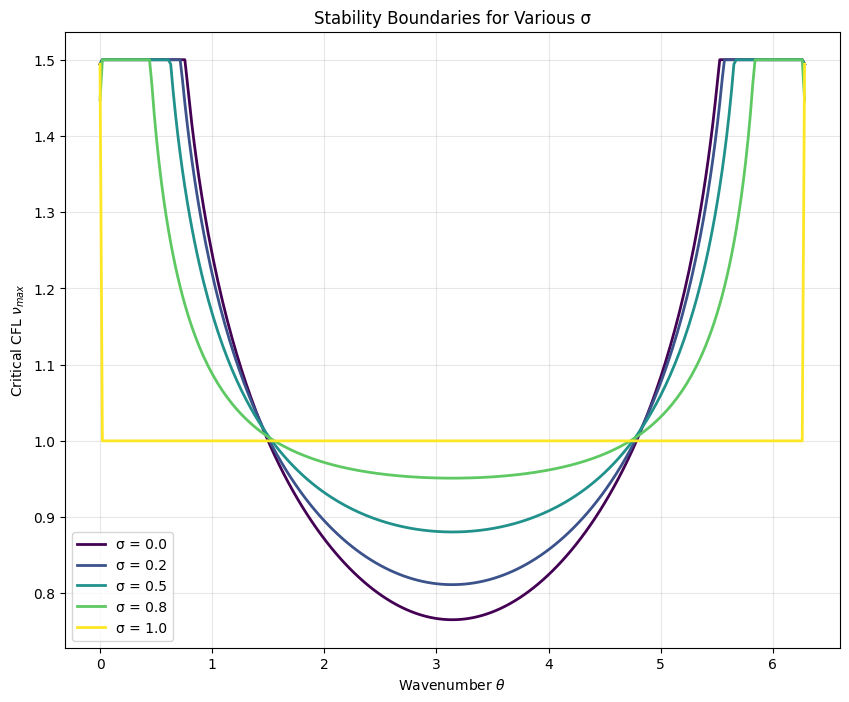

In [682]:
plot_stability_contours_multi_sigma()

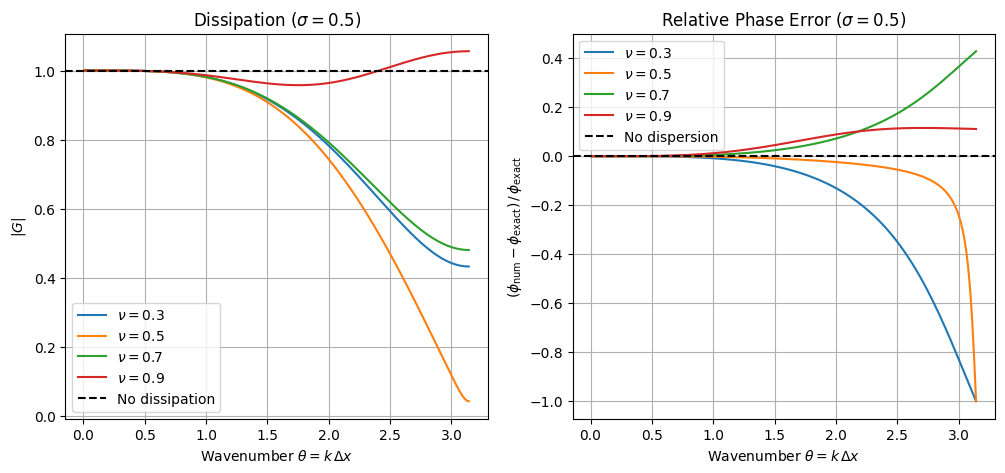

In [683]:
def dissipation_dispersion(
    sigma_value: np.floating,
    cfl_values: npt.NDArray[np.floating],
    n_theta: int,
):
    theta_values = np.linspace(0.01, np.pi, n_theta)
    # For stacked operation
    cfl_values = np.expand_dims(cfl_values, axis=-1)
    G_values = G_numeric(theta_values, cfl_values, sigma_value)
    phi_numeric = -np.angle(G_values)
    phi_exact = cfl_values * theta_values
    phase_errors = (phi_numeric - phi_exact) / (phi_exact + 1e-12)
    return theta_values, np.abs(G_values), phase_errors


def plot_dissipation(
    sigma_value: np.floating, *,
    cfl_values: npt.NDArray[np.floating],
    theta_values: npt.NDArray[np.floating],
    G_values: npt.NDArray[np.floating],
    ax: matplotlib.axes.Axes,
):
    for cfl_value, data in zip(cfl_values, G_values):
        ax.plot(theta_values, data, label=fr'$\nu = {cfl_value}$')

    ax.axhline(1.0, color='k', linestyle='--', label='No dissipation')
    ax.set_xlabel(r'Wavenumber $\theta = k\,\Delta x$')
    ax.set_ylabel(r'$|G|$')
    ax.set_title(rf'Dissipation ($\sigma = {sigma_value}$)')
    ax.legend()
    ax.grid(True)

    return ax


def plot_dispersion(
    sigma_value: np.floating, *,
    cfl_values: npt.NDArray[np.floating],
    theta_values: npt.NDArray[np.floating],
    phase_errors: npt.NDArray[np.floating],
    ax: matplotlib.axes.Axes,
):
    for cfl_value, data in zip(cfl_values, phase_errors):
        ax.plot(theta_values, data, label=fr'$\nu = {cfl_value}$')

    ax.axhline(0.0, color='k', linestyle='--', label='No dispersion')
    ax.set_xlabel(r'Wavenumber $\theta = k\,\Delta x$')
    ax.set_ylabel(
        r'$(\phi_{\mathrm{num}} - \phi_{\mathrm{exact}})\,/\,\phi_{\mathrm{exact}}$'
    )
    ax.set_title(rf'Relative Phase Error ($\sigma = {sigma_value}$)')
    ax.legend()
    ax.grid(True)

    return ax


def plot_dissipation_dispersion(
    sigma_value: np.floating = np.float64(0.5),
    cfl_values: npt.ArrayLike = (0.3, 0.5, 0.7, 0.9),  # pyright: ignore
    n_theta: int = 200,
    axes: tuple[matplotlib.axes.Axes, matplotlib.axes.Axes] | None = None,
):
    cfl_values: npt.NDArray[np.floating] = np.array(cfl_values)
    theta_values, G_values, phase_errors = dissipation_dispersion(
        sigma_value=sigma_value, cfl_values=cfl_values, n_theta=n_theta
    )

    if axes is None:
        fig, axes = plt.subplots(1, 2, figsize=(12, 5))
        # fig.set_layout_engine('tight')

    axes = typing.cast(tuple[matplotlib.axes.Axes, matplotlib.axes.Axes], axes)

    ax_dissipation, ax_dispersion = axes
    plot_dissipation(
        sigma_value=sigma_value, cfl_values=cfl_values,
        theta_values=theta_values, G_values=G_values, ax=ax_dissipation)
    plot_dispersion(
        sigma_value=sigma_value, cfl_values=cfl_values,
        theta_values=theta_values, phase_errors=phase_errors, ax=ax_dispersion)

    return axes


plot_dissipation_dispersion()
plt.show()

In [684]:
def dissipation_dispersion_analysis():
    """
    Analyze numerical dissipation and dispersion.
    
    For the exact solution: u(x,t) ∝ exp(i(kx - ωt)) with ω = ak (non-dispersive)
    
    Numerical scheme: G = |G| * exp(-i*φ) where
    - |G| < 1 → dissipation (amplitude decay)
    - φ ≠ ν*θ → dispersion (phase error)
    """
        
    # For exact advection: G_exact = exp(-i*ν*θ)
    G_exact = sp.exp(-sp.I * cfl * theta)
    
    # Numerical phase: φ = -arg(G)
    # Numerical amplitude: |G|
    
    G_trig = G.rewrite(sp.cos, sp.sin)
    G_real_part = sp.trigsimp(sp.re(G_trig))
    G_imag_part = sp.trigsimp(sp.im(G_trig))
    
    return G_real_part, G_imag_part

# G_re, G_im = dissipation_dispersion_analysis()

In [685]:
def find_stability_bounds():
    """
    Find constraints on ν (CFL) for stability.
    
    We need |G|² ≤ 1 for all θ. 
    The worst case is typically at θ = π (highest frequency).
    """
    
    print("Stability analysis at θ = π (worst case for many schemes):")
    print("="*60)
    
    G_at_pi = G.subs(theta, sp.pi)
    G_at_pi_simplified = sp.simplify(G_at_pi)
    
    display(Math(f"G(\\pi) = {sp.latex(G_at_pi_simplified)}"))
    
    G_mod_sq_pi = sp.simplify(sp.Abs(G_at_pi_simplified)**2)
    # Stencil is symmetrical => G is real
    G_mod_sq_pi = sp.simplify(G_at_pi_simplified**2)
    
    display(Math(f"|G(\\pi)|^2 = {sp.latex(G_mod_sq_pi)}"))
    
    # Stability: |G(π)|² ≤ 1
    stability_ineq = G_mod_sq_pi - 1
    stability_ineq_simplified = sp.simplify(stability_ineq)
    
    print("\nCondition |G(π)|² - 1 ≤ 0:")
    display(Math(f"{sp.latex(stability_ineq_simplified)} \\leq 0"))
    
    # Solve |G|² = 1 for critical CFL
    try:
        critical_cfl = sp.solve(stability_ineq_simplified, cfl)
        print("\nCritical CFL values (where |G| = 1):")
        for sol in critical_cfl:
            display(Math(f"\\nu = {sp.latex(sp.simplify(sol))}"))
    except Exception as e:
        print(f"Could not solve analytically: {e}")
    
    return G_at_pi_simplified, stability_ineq_simplified

# G_pi, stability_pi = find_stability_bounds()